In [1]:
#Check GPU

import torch

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [2]:
#Install the required packages
!pip install -q torch torchvision scikit-learn matplotlib

In [3]:
#Upload the dataset
from google.colab import files

uploaded = files.upload()

Saving robot_phase_dataset.zip to robot_phase_dataset.zip


In [4]:
#Extract the dataset
import zipfile
import os

zip_path = "robot_phase_dataset.zip"
extract_path = "/content/robot_phase_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print(os.listdir("/content/robot_phase_dataset"))

['place', 'README.txt', 'retreat', 'grasp', 'transport', 'metadata.csv', 'reach']


In [5]:
# Define the dataset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

data_dir = "/content/robot_phase_dataset"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['grasp', 'place', 'reach', 'retreat', 'transport']
Total images: 50


In [6]:
# Split the data into training and test dataset
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

Training images: 40
Test images: 10


In [7]:
# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

In [8]:
# Load pretrained ResNet-18
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

num_classes = len(dataset.classes)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


Linear(in_features=512, out_features=5, bias=True)


In [9]:
#Define loss and optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [10]:
# Train the model
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"| Loss: {running_loss/len(train_loader):.4f} "
        f"| Train Acc: {train_accuracy:.2f}%"
    )

Epoch 1/10 | Loss: 1.2557 | Train Acc: 57.50%
Epoch 2/10 | Loss: 0.4819 | Train Acc: 90.00%
Epoch 3/10 | Loss: 0.1629 | Train Acc: 97.50%
Epoch 4/10 | Loss: 0.0710 | Train Acc: 100.00%
Epoch 5/10 | Loss: 0.0418 | Train Acc: 100.00%
Epoch 6/10 | Loss: 0.0307 | Train Acc: 100.00%
Epoch 7/10 | Loss: 0.0200 | Train Acc: 100.00%
Epoch 8/10 | Loss: 0.0291 | Train Acc: 100.00%
Epoch 9/10 | Loss: 0.0276 | Train Acc: 100.00%
Epoch 10/10 | Loss: 0.0303 | Train Acc: 100.00%


In [11]:
# Evaluate
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test accuracy: {test_accuracy:.2f}%")

Test accuracy: 90.00%


True: transport
Prediction: transport


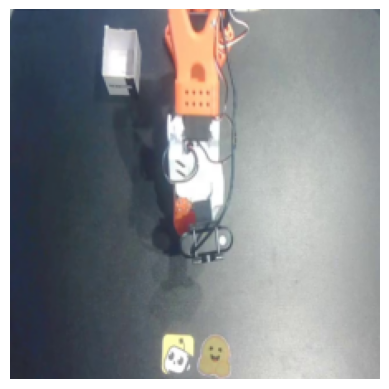

In [12]:
#Test one image manually
import matplotlib.pyplot as plt

image, label = test_dataset[0]

model.eval()

with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    predicted_class = output.argmax(dim=1).item()

true_label = dataset.classes[label]
predicted_label = dataset.classes[predicted_class]

print("True:", true_label)
print("Prediction:", predicted_label)

# Display image
image_display = image.permute(1, 2, 0).numpy()

# Undo normalization
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

image_display = image_display * std.numpy() + mean.numpy()
image_display = image_display.clip(0, 1)

plt.imshow(image_display)
plt.axis("off")
plt.show()

In [13]:
# Test all 10 images
model.eval()

for i in range(len(test_dataset)):

    image, label = test_dataset[i]

    with torch.no_grad():
        output = model(
            image.unsqueeze(0).to(device)
        )

        predicted_class = output.argmax(dim=1).item()

    true_label = dataset.classes[label]
    predicted_label = dataset.classes[predicted_class]

    print(
        f"True: {true_label:<10} | "
        f"Prediction: {predicted_label}"
    )

True: transport  | Prediction: transport
True: reach      | Prediction: reach
True: reach      | Prediction: reach
True: retreat    | Prediction: retreat
True: grasp      | Prediction: grasp
True: reach      | Prediction: reach
True: transport  | Prediction: transport
True: reach      | Prediction: reach
True: transport  | Prediction: transport
True: grasp      | Prediction: transport


In [14]:
# Save the model
torch.save(
    model.state_dict(),
    "/content/robot_phase_resnet18.pth"
)

print("Model saved.")

Model saved.
